In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb


In [9]:

df = pd.read_csv("Bank_Stock_Price_10Y.csv", parse_dates=['Date'], index_col='Date')

# Calculate daily returns
df['Daily_Return'] = df['Adj Close'].pct_change() * 100

# Drop first row (NaN Daily_Return)
df = df.dropna()


In [11]:
# Price-based features
df['MA5'] = df['Adj Close'].rolling(5).mean()
df['MA10'] = df['Adj Close'].rolling(10).mean()
df['Return_1'] = df['Daily_Return'].shift(1)
df['Return_2'] = df['Daily_Return'].shift(2)
df['Return_3'] = df['Daily_Return'].shift(3)

# Volatility
df['Volatility_5'] = df['Daily_Return'].rolling(5).std()
df['Volatility_10'] = df['Daily_Return'].rolling(10).std()

# Technical indicators
delta = df['Adj Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
df['RSI'] = 100 - (100 / (1 + rs))

ema12 = df['Adj Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Adj Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

df['BB_Mid'] = df['Adj Close'].rolling(20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2*df['Adj Close'].rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2*df['Adj Close'].rolling(20).std()

# Volume features
df['Volume_Change'] = df['Volume'].pct_change()
df['Volume_MA5'] = df['Volume'].rolling(5).mean()
df['Volume_MA10'] = df['Volume'].rolling(10).mean()

# Target variable
df['Target'] = (df['Daily_Return'].shift(-1) > 0).astype(int)

# Drop rows with NaN or inf
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Feature list
features = ['MA5','MA10','Return_1','Return_2','Return_3',
            'Volatility_5','Volatility_10','RSI','MACD','MACD_Signal',
            'BB_Upper','BB_Lower','Volume_Change','Volume_MA5','Volume_MA10']


In [13]:
split_index = int(len(df)*0.8)
X_train = df[features][:split_index]
X_test = df[features][split_index:]
y_train = df['Target'][:split_index]
y_test = df['Target'][split_index:]


In [15]:
# Train model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

# Predict probabilities
y_proba_rf = rf_model.predict_proba(X_test)[:,1]

# Threshold tuning
threshold = 0.3
y_pred_rf = (y_proba_rf > threshold).astype(int)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Confusion Matrix:
 [[ 25 236]
 [ 15 203]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.10      0.17       261
           1       0.46      0.93      0.62       218

    accuracy                           0.48       479
   macro avg       0.54      0.51      0.39       479
weighted avg       0.55      0.48      0.37       479



Top features:
 RSI              0.074510
Return_1         0.073176
Volume_Change    0.073041
Volume_MA10      0.072653
Volatility_10    0.072356
Return_3         0.072221
Volume_MA5       0.071310
Return_2         0.070721
MACD             0.067036
Volatility_5     0.066289
MACD_Signal      0.063834
BB_Upper         0.057343
MA10             0.055816
BB_Lower         0.055123
MA5              0.054569
dtype: float64


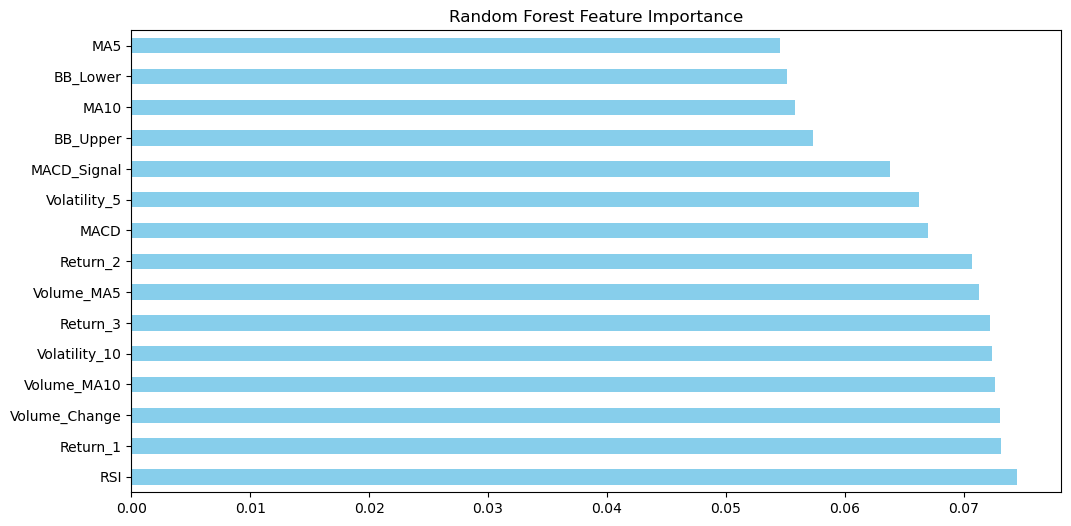

In [17]:
importances = rf_model.feature_importances_
feat_importance = pd.Series(importances, index=features).sort_values(ascending=False)

# Show top features
print("Top features:\n", feat_importance)

# Plot
plt.figure(figsize=(12,6))
feat_importance.plot(kind='barh', color='skyblue')
plt.title("Random Forest Feature Importance")
plt.show()

#Observation: Momentum, volume, and volatility


In [19]:
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []

for t in thresholds:
    y_pred_thresh = (y_proba_rf > t).astype(int)
    f1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    f1_scores.append(f1)

# Best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("Best threshold for Up class:", best_threshold)


Best threshold for Up class: 0.20999999999999996


In [21]:
y_pred_opt = (y_proba_rf > best_threshold).astype(int)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_opt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_opt))


Confusion Matrix:
 [[  1 260]
 [  0 218]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.01       261
           1       0.46      1.00      0.63       218

    accuracy                           0.46       479
   macro avg       0.73      0.50      0.32       479
weighted avg       0.75      0.46      0.29       479



In [ ]:
#low precision but good recall. good for finance